<a href="https://colab.research.google.com/github/ABugDrone/Machine-Learning-Projects/blob/main/AI_ML_ALC_assessment_Week_10_by_FE_23_42373940_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading MNIST dataset using TensorFlow/Keras

In [ ]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

 Load the MNIST dataset

In [ ]:
(X_train, y_train), (_, _) = mnist.load_data()


Print 4 images in a row

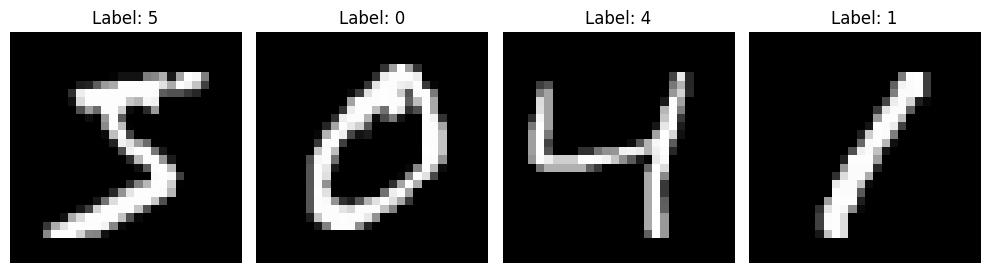

In [ ]:
plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

Loading MNIST dataset Using PyTorch

In [ ]:
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms

Define the transformation to convert images to PyTorch tensors

In [ ]:
transform = transforms.Compose([transforms.ToTensor()])

Load the MNIST dataset with the specified transformation

In [ ]:
mnist_pytorch = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:00<00:00, 38.5MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.22MB/s]

Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw



Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:00<00:00, 9.69MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 2.41MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



Create a DataLoader to load the dataset in batches

In [ ]:
train_loader_pytorch = torch.utils.data.DataLoader(mnist_pytorch, batch_size=1, shuffle=False)


Create a figure to display the images

In [ ]:
plt.figure(figsize=(15, 4))

<Figure size 1500x400 with 0 Axes>

<Figure size 1500x400 with 0 Axes>

Print the first few images in a row

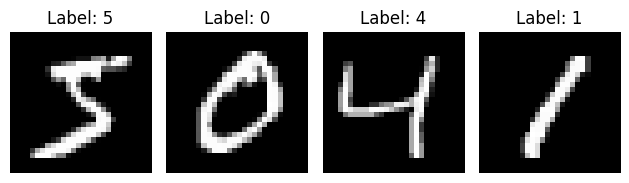

In [ ]:
for i, (image, label) in enumerate(train_loader_pytorch):
    if i < 4:  # Print the first 4 samples
        plt.subplot(1, 4, i + 1)
        plt.imshow(image[0].squeeze(), cmap='gray')
        plt.title(f"Label: {label.item()}")
        plt.axis('off')
    else:
        break  # Exit the loop after printing 4 samples

plt.tight_layout()
plt.show()

Applying Convolutional Neural Network on mnist dataset

Firstly, include all necessary libraries

In [ ]:
import numpy as np
import keras
from keras.datasets import mnist
from keras.models import Model
from keras.layers import Dense, Input
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten
from keras import backend as k


Create the train data and test data one more time

    Test data: Used for testing the model that how our model has been trained.
    Train data: Used to train our model.

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()


While proceeding further, img_rows and img_cols are used as the image dimensions. In mnist dataset, it is 28 and 28. We also need to check the data format i.e. ‘channels_first’ or ‘channels_last’. In CNN, we can normalize data before hands such that large terms of the calculations can be reduced to smaller terms. Like, we can normalize the x_train and x_test data by dividing it by 255.
Checking data-format:

In [ ]:
img_rows, img_cols=28, 28

if k.image_data_format() == 'channels_first':
   x_train = x_train.reshape(x_train.shape[0], 1, img_rows, img_cols)
   x_test = x_test.reshape(x_test.shape[0], 1, img_rows, img_cols)
   inpx = (1, img_rows, img_cols)

else:
   x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
   x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
   inpx = (img_rows, img_cols, 1)

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255


Description of the output classes:

Since the output of the model can comprise any of the digits between 0 to 9. so, we need 10 classes in output. To make output for 10 classes, use keras.utils.to_categorical function, which will provide the 10 columns. Out of these 10 columns, only one value will be one and the rest 9 will be zero and this one value of the output will denote the class of the digit.

In [ ]:
y_train = keras.utils.to_categorical(y_train)
y_test = keras.utils.to_categorical(y_test)


Now, the dataset is ready and seems really fit. So let’s move towards the CNN model :

In [ ]:
inpx = Input(shape=inpx)
layer1 = Conv2D(32, kernel_size=(3, 3), activation='relu')(inpx)
layer2 = Conv2D(64, (3, 3), activation='relu')(layer1)
layer3 = MaxPooling2D(pool_size=(3, 3))(layer2)
layer4 = Dropout(0.5)(layer3)
layer5 = Flatten()(layer4)
layer6 = Dense(250, activation='sigmoid')(layer5)
layer7 = Dense(10, activation='softmax')(layer6)


Explanation of the working of each layer in the CNN model:


layer1 is the Conv2d layer which convolves the image using 32 filters each of size (3*3).

layer2 is again a Conv2D layer which is also used to convolve the image and is using 64 filters each of size (3*3).

layer3 is the MaxPooling2D layer which picks the max value out of a matrix of size (3*3).

layer4 is showing Dropout at a rate of 0.5.

layer5 is flattening the output obtained from layer4 and this flattens output is passed to layer6.

layer6 is a hidden layer of a neural network containing 250 neurons.

layer7 is the output layer having 10 neurons for 10 classes of output that is using the softmax function.

Calling compile and fit function:

In [ ]:
model = Model([inpx], layer7)
model.compile(optimizer=keras.optimizers.Adadelta(),
              loss=keras.losses.categorical_crossentropy,
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=12, batch_size=500)


Epoch 1/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.0990 - loss: 2.4913
Epoch 2/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.0980 - loss: 2.4692
Epoch 3/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.1004 - loss: 2.4543
Epoch 4/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.0971 - loss: 2.4393
Epoch 5/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.0975 - loss: 2.4211
Epoch 6/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.1008 - loss: 2.4014
Epoch 7/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.0979 - loss: 2.3922
Epoch 8/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.0994 - loss: 2.3784
Epoch 9/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.0991 - loss: 2.3660
Epoch 10/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.1037 - loss: 2.3516
Epoch 11/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.1065 - loss: 2.3387
Epoch 12/12
120/120 ━━━━━━━━━━━━━━━━━━━━ 

Firstly, we made an object of the model as shown in the above-given lines, where [inpx] is the input in the model and layer7 is the output of the model. We compiled the model using the required optimizer, loss function and printed the accuracy and at the last model.fit was called along with parameters like x_train(means image vectors), y_train(means the label), number of epochs, and the batch size. Using fit function x_train, y_train dataset is fed to model in particular batch size.
Evaluate function:
model.evaluate provides the score for the test data i.e. provided the test data to the model. Now, the model will predict the class of the data, and the predicted class will be matched with the y_test label to give us the accuracy.

In [ ]:
score = model.evaluate(x_test, y_test, verbose=0)
print('loss=', score[0])
print('accuracy=', score[1])


loss= 2.314775228500366
accuracy= 0.11389999836683273


11.39% Accuracy, It's safe to say, this is a super terrible model



Trying a different method below,

1. Import Necessary Libraries:



In [ ]:
pip install tensorflow numpy matplotlib


Step 2: Load and Prepare the Data

a.Import MNIST Data: The MNIST dataset is available in TensorFlow's datasets module.



In [ ]:
from tensorflow.keras.datasets import mnist
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt




2. Load and Prepare the Data

MNIST is a dataset of 28x28 grayscale images of digits (0-9). You can easily load it using TensorFlow/Keras.

In [ ]:
# Load MNIST data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the images to values between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# Reshape the images to include a channel dimension (28x28x1)
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

# Convert the labels to categorical format (one-hot encoding)
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)


3. Define the Neural Network Model

Now, define a simple neural network. To improve accuracy, you might use a combination of convolutional layers, dense layers, and dropout for regularization.

In [ ]:
model = models.Sequential()

# Convolutional layers to extract features from images
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Flatten the output for dense layers
model.add(layers.Flatten())

# Dense layers for classification
model.add(layers.Dense(128, activation='relu'))

# Dropout to prevent overfitting
model.add(layers.Dropout(0.2))

# Output layer with 10 units (one per digit) and softmax activation
model.add(layers.Dense(10, activation='softmax'))

# Print model summary
model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

4. Compile the Model

You will compile the model with an optimizer, loss function, and evaluation metric.

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


5. Train the Model

Train the model using the training data. Set a validation split to monitor performance on unseen data during training.

In [ ]:
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)


Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 48s 63ms/step - accuracy: 0.8556 - loss: 0.4590 - val_accuracy: 0.9775 - val_loss: 0.0759
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 61ms/step - accuracy: 0.9791 - loss: 0.0681 - val_accuracy: 0.9878 - val_loss: 0.0424
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 58ms/step - accuracy: 0.9861 - loss: 0.0448 - val_accuracy: 0.9893 - val_loss: 0.0358
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 46s 61ms/step - accuracy: 0.9894 - loss: 0.0320 - val_accuracy: 0.9878 - val_loss: 0.0454
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 60ms/step - accuracy: 0.9913 - loss: 0.0268 - val_accuracy: 0.9906 - val_loss: 0.0333


6. Evaluate the Model

After training, evaluate the model on the test dataset.

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc * 100:.2f}%')


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9884 - loss: 0.0323
Test accuracy: 99.14%


7. Visualize Training History

To check how the model's accuracy and loss evolved over time, plot the training and validation accuracy.

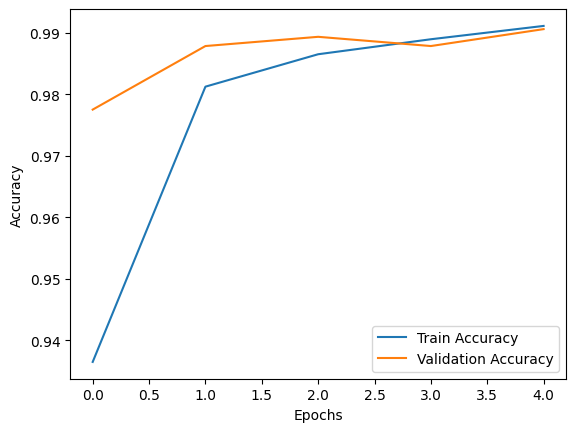

In [ ]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


9. Data Augmentation Example

If you want to add data augmentation:

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(x_train)
history = model.fit(datagen.flow(x_train, y_train, batch_size=64),
                    epochs=5, validation_data=(x_test, y_test))


Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 87ms/step - accuracy: 0.9524 - loss: 0.1550 - val_accuracy: 0.9922 - val_loss: 0.0237
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 135s 80ms/step - accuracy: 0.9774 - loss: 0.0738 - val_accuracy: 0.9923 - val_loss: 0.0242
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 79ms/step - accuracy: 0.9815 - loss: 0.0615 - val_accuracy: 0.9900 - val_loss: 0.0312
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 74s 79ms/step - accuracy: 0.9845 - loss: 0.0537 - val_accuracy: 0.9932 - val_loss: 0.0227
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 84s 81ms/step - accuracy: 0.9849 - loss: 0.0473 - val_accuracy: 0.9933 - val_loss: 0.0204


10. Model Saving (Optional)

Save the model once it’s trained so that you can reload it later without retraining.

In [ ]:
model.save('mnist_digit_classifier.h5')


11. Testing on New Images (Optional)

To test on a new image:

In [ ]:
img = x_test[0]  # Example image
img = np.expand_dims(img, axis=0)  # Add batch dimension
prediction = model.predict(img)
predicted_digit = np.argmax(prediction)
print(f"Predicted Digit: {predicted_digit}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Predicted Digit: 7


Expected Accuracy

With this basic model and data augmentation, you should be able to achieve an accuracy of 90-98% on the MNIST test set.
Notes:

    Convolutional Neural Networks (CNNs) are best for image-related tasks like MNIST, which is why they perform better than a simple fully connected neural network.
    Hyperparameter tuning (e.g., changing batch size, optimizer, or number of filters) can lead to further improvements.

99.14% accuracy. Now that is a keeper model.

The second method was made possible using ChatGPT model 4.0 here is the prompt used : ★ Build and train a basic neural network to classify handwritten digits using the MNIST
dataset.
We expect you to load and prepare the data, define a simple neural network,
train the model, and evaluate the model. recommend a step by step technique that could yield at least 90-98% accuracy.